In [1]:
import json

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

### Load the data

In [2]:
tasks_df = pd.read_csv("../assets/tasks.csv")
# tasks_df = tasks_df.loc[tasks_df["Task type"].isin(["Binary classification", "Multi-class classification", "Multi-label classification", "Regression"])]

In [3]:
models_df = pd.read_csv("../assets/models_min.csv")

In [ ]:
results_paths = {
    "Open-source":  "./results/finetuning/{task_id}/{version}/{model_id}/test_results.json",    
    "Proprietary": "./results/prompting/{shots_strategy}/{task_id}/{model_id}/test_results.json",
    "Baseline": "./results/baselines/{model_id}/{task_id}/test_results.json"
}

In [5]:
metrics = {
    "Regression": "smape",
    "NER": "overall_f1",
    "MLM": "accuracy",
    "default": "f1_macro"
}

In [6]:
models_v4 = ["llama3.2-1b", "llama3.2-3b", "starcoder2-3b", "starcoder2-7b"]
tasks_v4 = ["functional_requirement", "incivility", "quality_requirement", "safety_issue", "security_requirement", "tone_bearing",
            "commit_intent", "issue_intention", "review_type",
            "comment_type_java", "comment_type_pharo", "comment_type_python", "review_aspect", "smell_doc"]

In [7]:
all_results = []


def load_results(path):
    with open(path, "r") as f:
        results = json.load(f)
        results = {k.replace("eval_", ""): v for k, v in results.items()}
    
    if task["Task type"] in metrics.keys():
        metric = metrics[task["Task type"]]
    else:
        metric = metrics["default"]

    row = task.to_dict() | model.to_dict()
    row["Score"] = results[metric]
    if "epoch" in results:
        row["Epoch"] = results["epoch"]

    return row


for i, task in tasks_df.iterrows():
    print(f"\nINFO: Working on task={task["Task ID"]}\n---")
    for j, model in models_df.iterrows():
        if model["Model type"] == "Proprietary":
                path_ = results_paths[model["Model type"]].format(
                    shots_strategy=model["Shots strategy"],
                    task_id=task["Task ID"],
                    model_id=model["Model ID"]
                )
        elif model["Model type"] == "Open-source":
            if (model["Model ID"] in models_v4) and (task["Task ID"] in tasks_v4):
                version = "v4"
                print(f"INFO: Loading {version} for model={model["Model ID"]} task={task["Task ID"]}")
            else:
                version = "v3"
            path_ = results_paths[model["Model type"]].format(
                task_id=task["Task ID"],
                version=version,
                model_id=model["Model ID"]
            )
        else:
            path_ = results_paths[model["Model type"]].format(
                model_id=model["Model ID"],
                task_id=task["Task ID"]
            )

        try:
            row = load_results(path_)
            all_results.append(row)
        except FileNotFoundError:
            print(f"ERR: Results not found for for model={model["Model ID"]} task={task["Task ID"]}, path= {path_}")
            # print(f" - INFO: Temporally loading previous results")
            # path_ = path_.replace("v4", "v3")
            # row = load_results(path_)
            # all_results.append(row)

all_results_df = pd.DataFrame(all_results)

# Calculating the inverse value of sMAPE (1-sMAPE)
all_results_df["Score"] = all_results_df.apply(lambda x: (1 - x["Score"]) if x["Task type"] == "Regression" else x["Score"], axis=1)


INFO: Working on task=bug_issue
---

INFO: Working on task=functional_requirement
---
INFO: Loading v4 for model=llama3.2-1b task=functional_requirement
INFO: Loading v4 for model=llama3.2-3b task=functional_requirement
INFO: Loading v4 for model=starcoder2-3b task=functional_requirement
INFO: Loading v4 for model=starcoder2-7b task=functional_requirement

INFO: Working on task=incivility
---
INFO: Loading v4 for model=llama3.2-1b task=incivility
INFO: Loading v4 for model=llama3.2-3b task=incivility
INFO: Loading v4 for model=starcoder2-3b task=incivility
INFO: Loading v4 for model=starcoder2-7b task=incivility

INFO: Working on task=quality_requirement
---
INFO: Loading v4 for model=llama3.2-1b task=quality_requirement
INFO: Loading v4 for model=llama3.2-3b task=quality_requirement
INFO: Loading v4 for model=starcoder2-3b task=quality_requirement
INFO: Loading v4 for model=starcoder2-7b task=quality_requirement

INFO: Working on task=safety_issue
---
INFO: Loading v4 for model=llama

In [8]:
all_results_df.shape

(580, 15)

In [9]:
all_results_df.sample(5)

,Task type,Task ID,Activity,Family,Source,Model ID,Model name,Model architecture,Model size,Number of parameters,Domain adaptation,Model type,Shots strategy,Score,Epoch
106,Binary classification,quality_requirement,Requirements analysis,Core non-code,Requirements specifications,gpt-4o-2024-08-06,GPT-4o (zero-shot),Decoder-only,NaN,NaN,Generalist,Proprietary,zero,0.733066,NaN
521,Multi-label classification,smell_doc,Quality assurance,Code-adjacent metadata,API documentations,codellama-7b,CodeLlama 7B,Decoder-only,Billion params.,6.607409e+09,Domain-adapted,Open-source,NaN,0.621861,5.0
118,Binary classification,safety_issue,Quality assurance,Code-adjacent metadata,Issue tracking systems,gpt2-small,GPT-2 small,Decoder-only,Million params.,1.244398e+08,Generalist,Open-source,NaN,0.855571,6.0
394,Multi-label classification,comment_type_java,Software development,Code-adjacent metadata,Code repositories,roberta-base,RoBERTa base,Encoder-only,Million params.,1.246456e+08,Generalist,Open-source,NaN,0.772129,10.0
565,NER,se_entities,Software development,Core non-code,Developer forums,modernbert-large,ModernBERT large,Encoder-only,Million params.,3.947817e+08,Generalist,Open-source,NaN,0.469396,20.0


### Arrange/aggregate results

In [10]:
all_results_pivoted_df = all_results_df.pivot(columns=["Model type", "Domain adaptation", "Model architecture", "Model name"], index=["Task type", "Task ID"], values=["Score"]).droplevel(level=0, axis=1).round(3)
all_results_pivoted_df

Model type                                         Open-source             \
Domain adaptation                                   Generalist              
Model architecture                                Encoder-only              
Model name                                           BERT base BERT large   
Task type                  Task ID                                          
Binary classification      bug_issue                     0.864      0.873   
                           functional_requirement        0.843      0.843   
                           incivility                    0.751      0.758   
                           quality_requirement           0.834      0.854   
                           safety_issue                  0.854      0.860   
                           security_requirement          0.936      0.389   
                           tone_bearing                  0.650      0.709   
MLM                        requirement_completion        0.500      0.525   
Multi-class classification closed_question               0.533      0.555   
                           commit_intent                 0.719      0.642   
                           issue_intention               0.843      0.850   
                           issue_type                    0.782      0.786   
                           question_quality              0.848      0.841   
                           review_type                   0.786      0.392   
                           sentiment                     0.803      0.801   
Multi-label classification comment_type_java             0.768      0.789   
                           comment_type_pharo            0.522      0.545   
                           comment_type_python           0.574      0.484   
                           review_aspect                 0.406      0.119   
                           smell_doc                     0.583      0.155   
NER                        se_entities                   0.411      0.492   
Regression                 story_points                  0.422      0.283   

Model type                                                                    \
Domain adaptation                                                              
Model architecture                                                             
Model name                                        RoBERTa base RoBERTa large   
Task type                  Task ID                                             
Binary classification      bug_issue                     0.873         0.883   
                           functional_requirement        0.739         0.856   
                           incivility                    0.771         0.411   
                           quality_requirement           0.802         0.840   
                           safety_issue                  0.850         0.845   
                           security_requirement          0.915         0.389   
                           tone_bearing                  0.680         0.465   
MLM                        requirement_completion        0.626         0.665   
Multi-class classification closed_question               0.550         0.569   
                           commit_intent                 0.750         0.192   
                           issue_intention               0.866         0.855   
                           issue_type                    0.792         0.798   
                           question_quality              0.857         0.866   
                           review_type                   0.775         0.747   
                           sentiment                     0.802         0.806   
Multi-label classification comment_type_java             0.772         0.643   
                           comment_type_pharo            0.529         0.435   
                           comment_type_python           0.638         0.105   
                           review_aspect                 0.424         0.000   


In [11]:
all_results_pivoted_df.to_csv("./results.csv")

In [12]:
all_results_df["Model type - Domain adaptation"] = all_results_df[["Model type", "Domain adaptation"]].apply(lambda x: x["Model type"] + " - " + str(x["Domain adaptation"]), axis=1)

In [13]:
all_results_df.loc[~all_results_df["Task type"].isin(["NER", "MLM"])].groupby(["Family", "Model type - Domain adaptation"]).agg({"Score": ["mean", "std"]}).droplevel(level=0, axis=1).unstack(level="Model type - Domain adaptation").swaplevel(axis=1).sort_index(ascending= [False, True],axis=1).round(3)

Model type - Domain adaptation Proprietary - Generalist         \
                                                   mean    std   
Family                                                           
Code-adjacent metadata                            0.584  0.199   
Core non-code                                     0.633  0.273   
Developer communication                           0.527  0.155   

Model type - Domain adaptation Open-source - Generalist         \
                                                   mean    std   
Family                                                           
Code-adjacent metadata                            0.723  0.154   
Core non-code                                     0.670  0.234   
Developer communication                           0.722  0.122   

Model type - Domain adaptation Open-source - Domain-adapted         \
                                                       mean    std   
Family                                                               
Code-adjacent metadata                                0.739  0.148   
Core non-code                                         0.694  0.196   
Developer communication                               0.694  0.131   

Model type - Domain adaptation Baseline - nan         
                                         mean    std  
Family                                                
Code-adjacent metadata                  0.657  0.121  
Core non-code                           0.527  0.216  
Developer communication                 0.623  0.104

In [14]:
all_results_df.loc[~all_results_df["Task type"].isin(["NER", "MLM"])].groupby(["Source", "Model type - Domain adaptation"]).agg({"Score": ["mean", "std"]}).droplevel(level=0, axis=1).unstack(level="Model type - Domain adaptation").swaplevel(axis=1).sort_index(ascending= [False, True],axis=1).round(3)

Model type - Domain adaptation         Proprietary - Generalist         \
                                                           mean    std   
Source                                                                   
API documentations                                        0.372  0.166   
App stores                                                0.760  0.009   
Code repositories                                         0.459  0.148   
Code repositories + Developer forums                      0.702  0.019   
Developer forums                                          0.410  0.040   
Issue tracking systems                                    0.635  0.268   
Issue tracking systems + Mailing lists                    0.576  0.148   
Requirements specifications                               0.820  0.051   

Model type - Domain adaptation         Open-source - Generalist         \
                                                           mean    std   
Source                                                                   
API documentations                                        0.570  0.128   
App stores                                                0.712  0.124   
Code repositories                                         0.644  0.149   
Code repositories + Developer forums                      0.798  0.019   
Developer forums                                          0.607  0.215   
Issue tracking systems                                    0.748  0.191   
Issue tracking systems + Mailing lists                    0.701  0.095   
Requirements specifications                               0.840  0.109   

Model type - Domain adaptation         Open-source - Domain-adapted         \
                                                               mean    std   
Source                                                                       
API documentations                                            0.595  0.078   
App stores                                                    0.738  0.039   
Code repositories                                             0.674  0.165   
Code repositories + Developer forums                          0.783  0.020   
Developer forums                                              0.641  0.168   
Issue tracking systems                                        0.757  0.173   
Issue tracking systems + Mailing lists                        0.630  0.103   
Requirements specifications                                   0.835  0.128   

Model type - Domain adaptation         Baseline - nan         
                                                 mean    std  
Source                                                        
API documentations                              0.664  0.071  
App stores                                      0.552  0.126  
Code repositories                               0.562  0.115  
Code repositories + Developer forums            0.607  0.027  
Developer forums                                0.512  0.236  
Issue tracking systems                          0.659  0.195  
Issue tracking systems + Mailing lists          0.629  0.023  
Requirements specifications                     0.677  0.146

In [15]:
all_results_df.loc[~all_results_df["Task type"].isin(["NER", "MLM"])].groupby(["Activity", "Model type - Domain adaptation"]).agg({"Score": ["mean", "std"]}).droplevel(level=0, axis=1).unstack(level="Model type - Domain adaptation").swaplevel(axis=1).sort_index(ascending= [False, True],axis=1).round(3)

Model type - Domain adaptation Proprietary - Generalist         \
                                                   mean    std   
Activity                                                         
Quality assurance                                 0.601  0.214   
Requirements analysis                             0.820  0.051   
Software development                              0.380  0.049   
Software maintenance                              0.730  0.039   
Software management                               0.461  0.211   

Model type - Domain adaptation Open-source - Generalist         \
                                                   mean    std   
Activity                                                         
Quality assurance                                 0.674  0.222   
Requirements analysis                             0.840  0.109   
Software development                              0.631  0.151   
Software maintenance                              0.760  0.115   
Software management                               0.664  0.173   

Model type - Domain adaptation Open-source - Domain-adapted         \
                                                       mean    std   
Activity                                                             
Quality assurance                                     0.703  0.171   
Requirements analysis                                 0.835  0.128   
Software development                                  0.653  0.185   
Software maintenance                                  0.780  0.056   
Software management                                   0.649  0.158   

Model type - Domain adaptation Baseline - nan         
                                         mean    std  
Activity                                              
Quality assurance                       0.629  0.230  
Requirements analysis                   0.677  0.146  
Software development                    0.537  0.124  
Software maintenance                    0.654  0.089  
Software management                     0.569  0.159

In [16]:
all_results_df.groupby(["Task type", "Model type - Domain adaptation"]).agg({"Score": ["mean", "std"]}).droplevel(level=0, axis=1).unstack(level="Model type - Domain adaptation").swaplevel(axis=1).sort_index(ascending= [False, True],axis=1).round(3)

Model type - Domain adaptation Proprietary - Generalist         \
                                                   mean    std   
Task type                                                        
Binary classification                             0.742  0.137   
MLM                                                 NaN    NaN   
Multi-class classification                        0.629  0.158   
Multi-label classification                        0.392  0.081   
NER                                                 NaN    NaN   
Regression                                        0.129  0.118   

Model type - Domain adaptation Open-source - Generalist         \
                                                   mean    std   
Task type                                                        
Binary classification                             0.806  0.110   
MLM                                               0.620  0.088   
Multi-class classification                        0.750  0.124   
Multi-label classification                        0.575  0.173   
NER                                               0.478  0.071   
Regression                                        0.377  0.068   

Model type - Domain adaptation Open-source - Domain-adapted         \
                                                       mean    std   
Task type                                                            
Binary classification                                 0.783  0.140   
MLM                                                   0.624    NaN   
Multi-class classification                            0.761  0.098   
Multi-label classification                            0.611  0.160   
NER                                                   0.528  0.016   
Regression                                            0.424  0.047   

Model type - Domain adaptation Baseline - nan         
                                         mean    std  
Task type                                             
Binary classification                   0.694  0.111  
MLM                                       NaN    NaN  
Multi-class classification              0.639  0.109  
Multi-label classification              0.512  0.171  
NER                                       NaN    NaN  
Regression                              0.297  0.062

In [17]:
all_results_df.sort_values("Score", ascending=False).groupby(["Task ID"]).head(1)[["Task type", "Task ID", "Model name", "Score"]].sort_values(["Task type", "Task ID"])

,Task type,Task ID,Model name,Score
17,Binary classification,bug_issue,CodeLlama 7B,0.884611
35,Binary classification,functional_requirement,GPT-2 medium,0.874485
64,Binary classification,incivility,GPT-2 large,0.815476
98,Binary classification,quality_requirement,T5 large,0.863859
116,Binary classification,safety_issue,ModernBERT base,0.876193
161,Binary classification,security_requirement,CodeT5+ 770M,0.978535
179,Binary classification,tone_bearing,Llama 3.2 3B,0.741040
578,MLM,requirement_completion,ModernBERT large,0.708776
213,Multi-class classification,closed_question,CodeLlama 7B,0.589785
242,Multi-class classification,commit_intent,StarCoder2 3B,0.779642


### Visualize the data

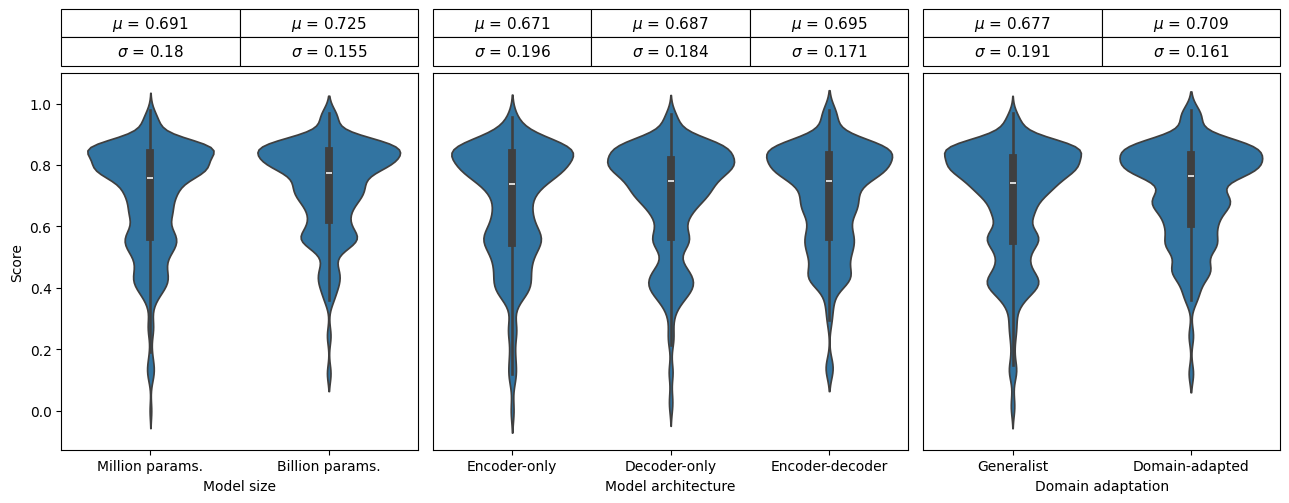

In [18]:
def plot_subplot(df, categorical_col, ax):
    sns.violinplot(data=df, x=categorical_col, y="Score", bw_adjust=0.5, ax=ax)

    stats_t = df.groupby(categorical_col).agg(
        mean=("Score", lambda x: "$\\mu$ = " + str(round(pd.Series.mean(x), 3))),
        std=("Score", lambda x: "$\\sigma$ = " + str(round(pd.Series.std(x), 3)))
    ).reindex([tick.get_text() for tick in ax.get_xticklabels()]).T

    table = ax.table(
        cellText=stats_t.values,
        loc="top",
        cellLoc="center",
        bbox=[0, 1.02, 1, 0.15]
    )
    table.auto_set_font_size(False)
    table.set_fontsize(11)

    lw = ax.spines["bottom"].get_linewidth()
    for cell in table.get_celld().values():
        cell.set_linewidth(lw)

fig, axes = plt.subplots(1, 3, sharey=True, figsize=(13, 5), gridspec_kw={'width_ratios': [0.3, 0.4, 0.3]})

plot_subplot(all_results_df, "Model size", axes[0])
plot_subplot(all_results_df, "Model architecture", axes[1])
plot_subplot(all_results_df, "Domain adaptation", axes[2])

for ax in axes[1:]:
    ax.tick_params(axis="y", which="both", left=False, labelleft=False)

plt.subplots_adjust(top=0.7, wspace=0.02)

plt.tight_layout()

# plt.savefig("dists_by_drivers.pdf", format="pdf", bbox_inches="tight")

plt.show()

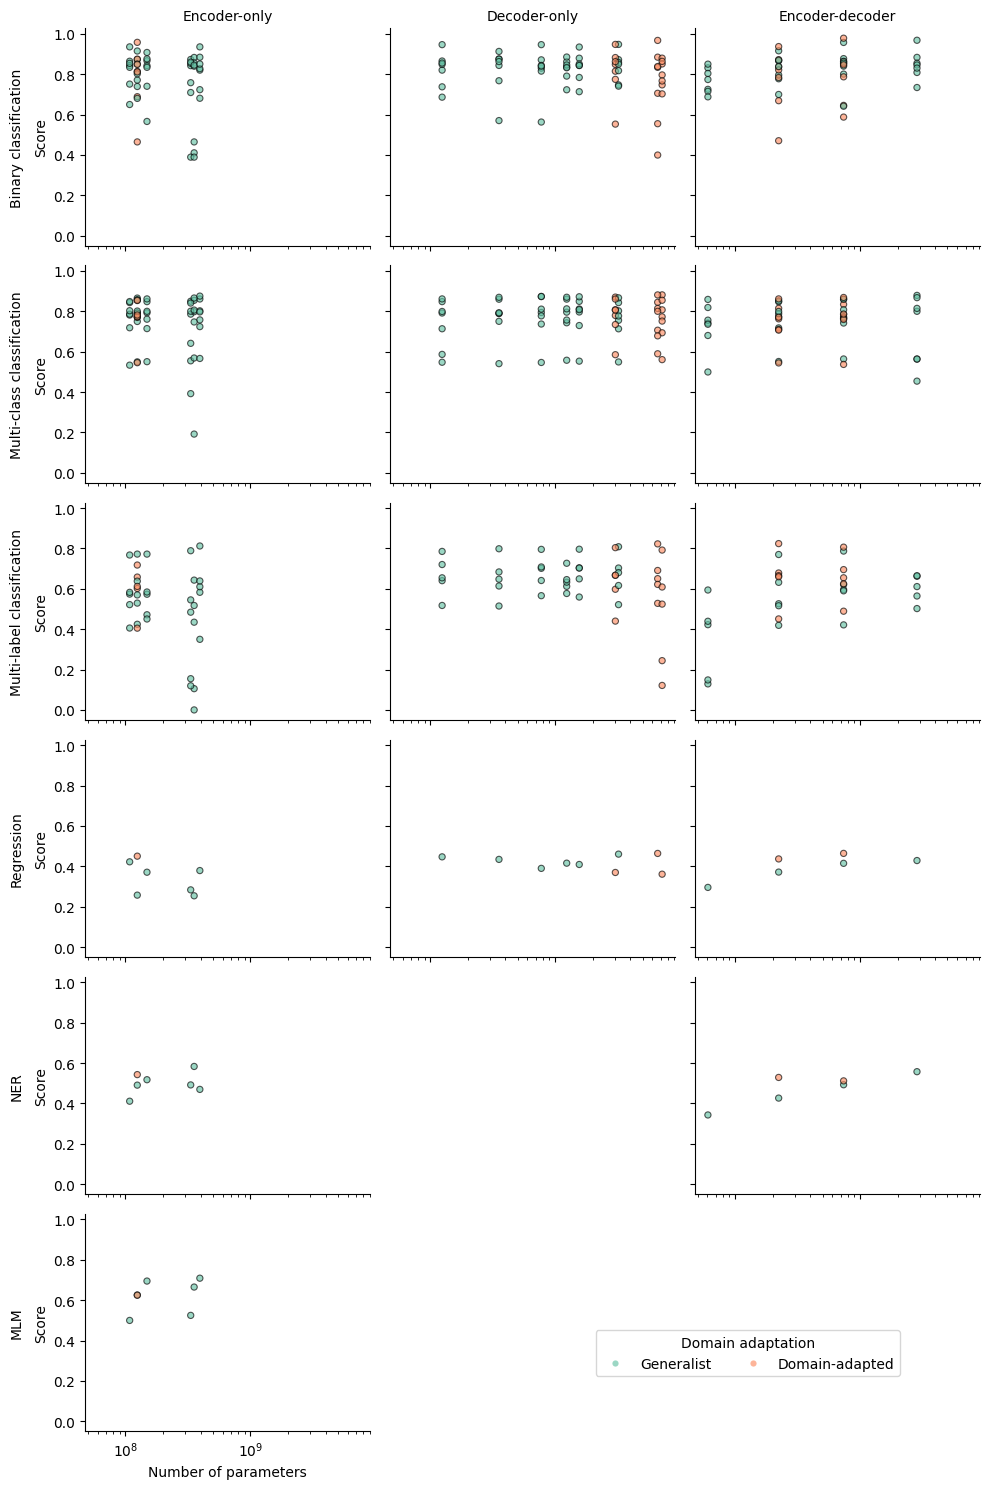

In [19]:
g = sns.relplot(
    data=all_results_df,
    x="Number of parameters",
    y="Score",
    hue="Domain adaptation",
    palette=["#66c2a5", "#fc8d62"],
    s=20,
    alpha=0.65,
    edgecolors="black",
    linewidths=0.8,
    col="Model architecture",
    row="Task type",
    kind="scatter"
)

g.set(xscale="log")

g.set_titles(col_template="{col_name}", row_template="{row_name}")
for i, _ in enumerate(g.row_names):
    for j, col_val in enumerate(g.col_names):
        ax = g.axes[i, j]
        if i == 0:
            ax.set_title(col_val, fontsize=10)
        else:
            ax.set_title("")

g.fig.subplots_adjust(hspace=0.1)
g.fig.set_size_inches(10, 15)

# Remove subplots with no data
for i, row_val in enumerate(g.row_names):
    for j, col_val in enumerate(g.col_names):
        # subset the DataFrame to see if there are any rows for this facet
        facet_df = all_results_df[
            (all_results_df["Task type"] == row_val)
            & (all_results_df["Model architecture"] == col_val)
        ]
        if facet_df.empty:
            ax_empty = g.axes[i, j]
            ax_empty.set_visible(False)

for i, row_val in enumerate(g.row_names):
    # Grab the leftmost Axes for this row
    ax_left = g.axes[i, 0]
    # Place text to the left of that axis, vertically centered
    ax_left.annotate(
        row_val,
        xy=(0, 0.5),               # use the axis’s left edge at half‐height
        xytext=(-ax_left.yaxis.labelpad - 40, 0),
        xycoords="axes fraction",  # (0,0) is lower‐left, (1,1) is upper‐right of that Axes
        textcoords="offset points",
        ha="right", va="center",
        fontsize=10,
        rotation=90
    )

sns.move_legend(
    g,
    loc="center",
    bbox_to_anchor=g.axes[-1, -1].get_position(),
    ncols=3,
    frameon=True
)

plt.tight_layout()

# plt.savefig("dists_by_drivers_and_tasktype.pdf", format="pdf", bbox_inches="tight")

plt.show()

In [20]:
all_results_df.groupby(
    all_results_df["Task type"].isin(["MLM", "NER"]).replace({True: "NER/MLM (50 epochs)", False: "Classification/Regression (10 epochs)"})
)["Epoch"].describe(percentiles=[.7, .8, .9])

,count,mean,std,min,50%,70%,80%,90%,max
Task type,,,,,,,,,
Classification/Regression (10 epochs),439.0,7.002506,2.049649,1.499857,7.0,8.0,10.0,10.0,10.0
NER/MLM (50 epochs),20.0,22.500000,6.977407,20.000000,20.0,20.0,21.0,25.5,50.0
